In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all datasets
rta = pd.read_csv('RTA Dataset.csv')
nepal_national = pd.read_csv('nepal_road_accidents.csv')
nepal_district = pd.read_csv('nepal_district_accidents_2019_2022.csv')
kathmandu = pd.read_csv('kathmandu_valley_accidents.csv')
causes = pd.read_csv('nepal_accident_causes.csv')
vehicles = pd.read_csv('nepal_vehicle_type_accidents.csv')

print("=== RTA Dataset (Main ML Data) ===")
print(f"Shape: {rta.shape}")
print(f"Columns: {list(rta.columns)}")
print("\n=== Nepal National Data ===")
print(f"Shape: {nepal_national.shape}")
print("\n=== Kathmandu Valley Data ===")
print(f"Shape: {kathmandu.shape}")

=== RTA Dataset (Main ML Data) ===
Shape: (12316, 32)
Columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']

=== Nepal National Data ===
Shape: (11, 8)

=== Kathmandu Valley Data ===
Shape: (9, 7)


In [2]:
# Cell 2 — First look at the data
print("=== First 3 rows ===")
print(rta.head(3))

print("\n=== Data Types ===")
print(rta.dtypes)

print("\n=== Missing Values ===")
missing = rta.isnull().sum()
missing_pct = (missing / len(rta) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== Target Column Distribution ===")
print(rta['Accident_severity'].value_counts())
print("\nTarget %:")
print(rta['Accident_severity'].value_counts(normalize=True).mul(100).round(2))


=== First 3 rows ===
       Time Day_of_week Age_band_of_driver Sex_of_driver   Educational_level  \
0  17:02:00      Monday              18-30          Male   Above high school   
1  17:02:00      Monday              31-50          Male  Junior high school   
2  17:02:00      Monday              18-30          Male  Junior high school   

  Vehicle_driver_relation Driving_experience      Type_of_vehicle  \
0                Employee              1-2yr           Automobile   
1                Employee         Above 10yr  Public (> 45 seats)   
2                Employee              1-2yr      Lorry (41?100Q)   

  Owner_of_vehicle Service_year_of_vehicle  ... Vehicle_movement  \
0            Owner              Above 10yr  ...   Going straight   
1            Owner                 5-10yrs  ...   Going straight   
2            Owner                     NaN  ...   Going straight   

    Casualty_class Sex_of_casualty Age_band_of_casualty Casualty_severity  \
0               na             

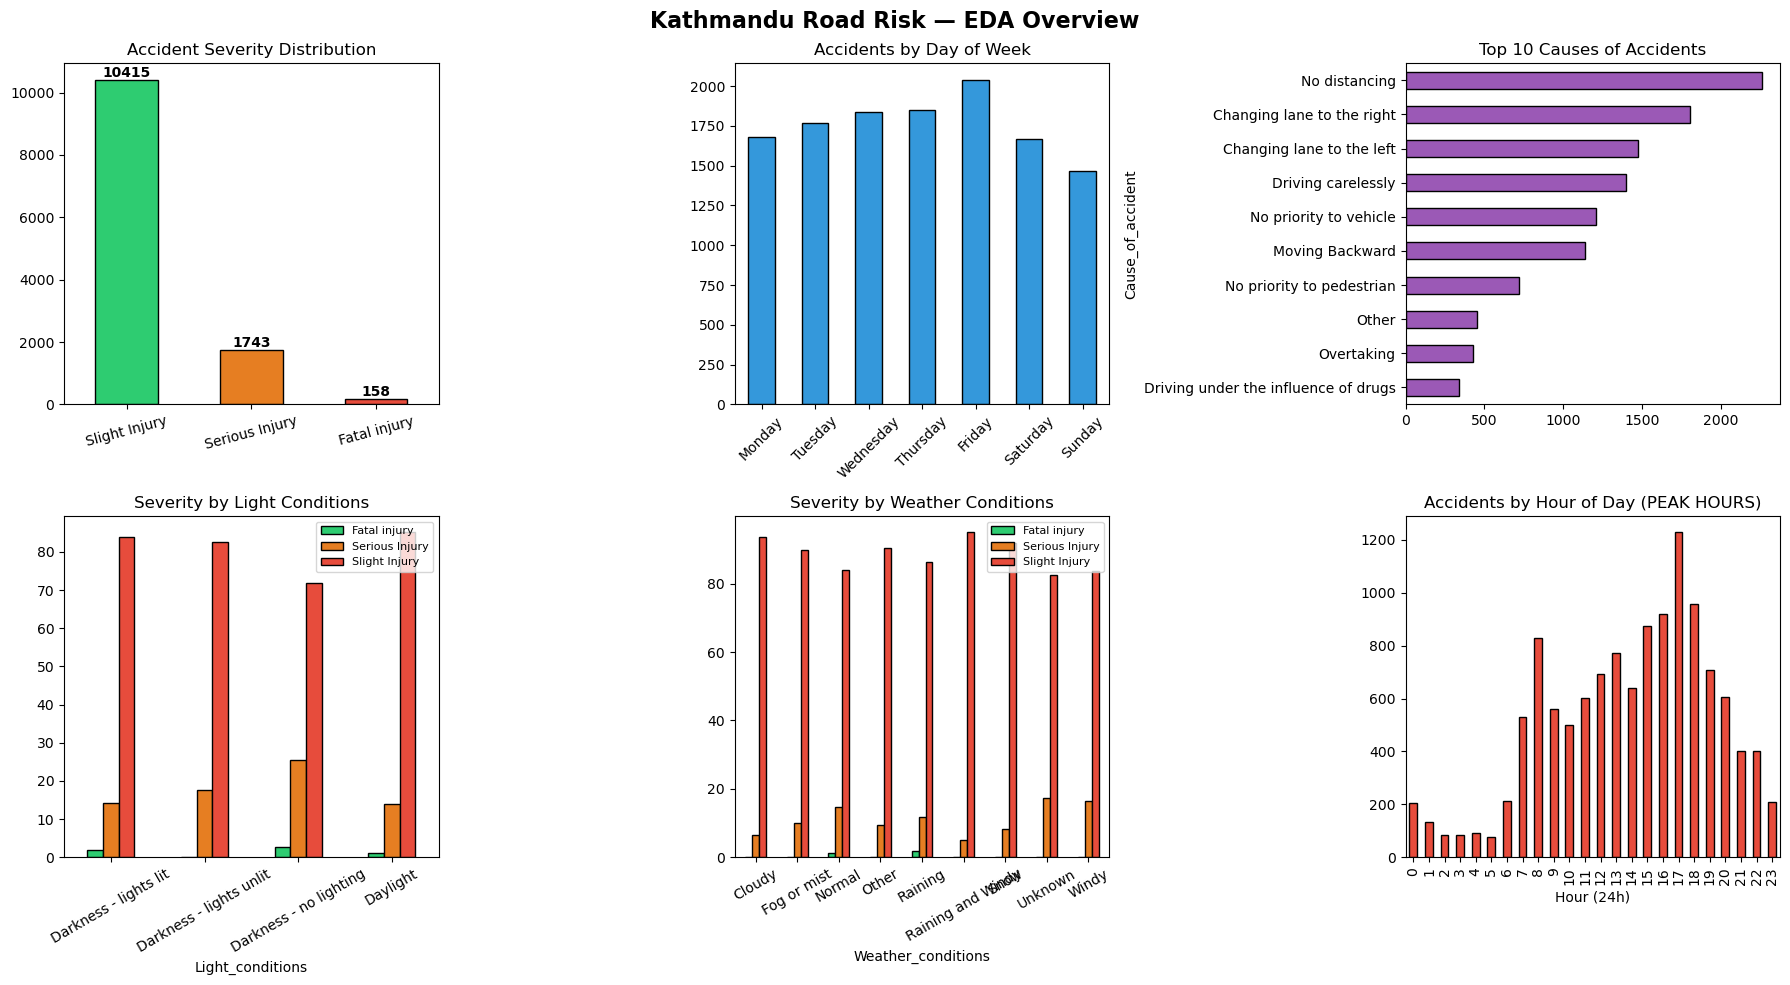

Saved as eda_overview.png

=== TOP 5 PEAK ACCIDENT HOURS ===
Hour
17    1228
18     956
16     921
15     874
8      828
Name: count, dtype: int64

=== TOP 10 CAUSES ===
Cause_of_accident
No distancing                           2263
Changing lane to the right              1808
Changing lane to the left               1473
Driving carelessly                      1402
No priority to vehicle                  1207
Moving Backward                         1137
No priority to pedestrian                721
Other                                    456
Overtaking                               430
Driving under the influence of drugs     340
Name: count, dtype: int64


In [3]:
# Cell 3 — Visualize the key patterns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Kathmandu Road Risk — EDA Overview', fontsize=16, fontweight='bold')

# Plot 1 — Target distribution
colors = ['#2ecc71', '#e67e22', '#e74c3c']
rta['Accident_severity'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=colors, edgecolor='black'
)
axes[0,0].set_title('Accident Severity Distribution')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=15)
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontweight='bold')

# Plot 2 — Accidents by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = rta['Day_of_week'].value_counts().reindex(day_order)
day_counts.plot(kind='bar', ax=axes[0,1], color='#3498db', edgecolor='black')
axes[0,1].set_title('Accidents by Day of Week')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 — Top 10 Causes
top_causes = rta['Cause_of_accident'].value_counts().head(10)
top_causes.plot(kind='barh', ax=axes[0,2], color='#9b59b6', edgecolor='black')
axes[0,2].set_title('Top 10 Causes of Accidents')
axes[0,2].invert_yaxis()

# Plot 4 — Light conditions vs Severity
light_sev = pd.crosstab(rta['Light_conditions'], rta['Accident_severity'], normalize='index') * 100
light_sev.plot(kind='bar', ax=axes[1,0], color=colors, edgecolor='black')
axes[1,0].set_title('Severity by Light Conditions')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend(fontsize=8)

# Plot 5 — Weather vs Severity
weather_sev = pd.crosstab(rta['Weather_conditions'], rta['Accident_severity'], normalize='index') * 100
weather_sev.plot(kind='bar', ax=axes[1,1], color=colors, edgecolor='black')
axes[1,1].set_title('Severity by Weather Conditions')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(fontsize=8)

# Plot 6 — Hour of day extraction
rta['Hour'] = pd.to_datetime(rta['Time'], format='%H:%M:%S', errors='coerce').dt.hour
hour_counts = rta['Hour'].value_counts().sort_index()
hour_counts.plot(kind='bar', ax=axes[1,2], color='#e74c3c', edgecolor='black')
axes[1,2].set_title('Accidents by Hour of Day (PEAK HOURS)')
axes[1,2].set_xlabel('Hour (24h)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as eda_overview.png")

# Print peak hours summary
print("\n=== TOP 5 PEAK ACCIDENT HOURS ===")
print(hour_counts.sort_values(ascending=False).head(5))

print("\n=== TOP 10 CAUSES ===")
print(rta['Cause_of_accident'].value_counts().head(10))

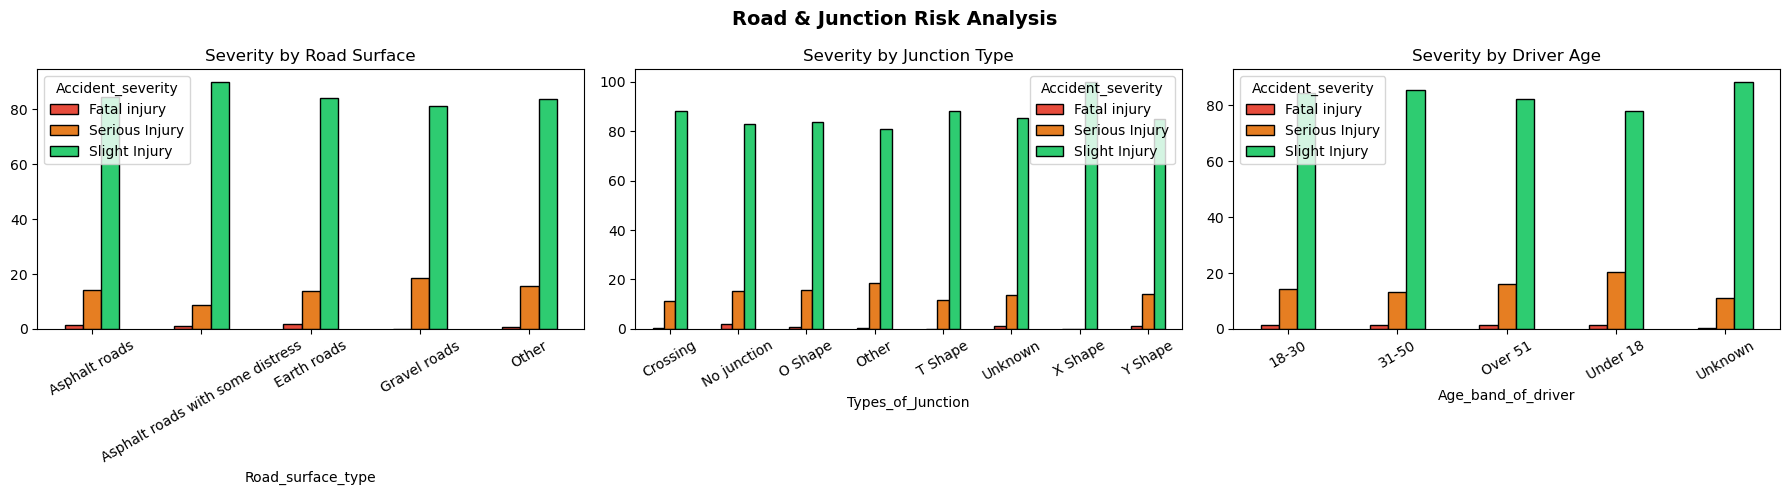

=== FEATURE SHORTLIST FOR MODEL ===

-- Columns to KEEP (useful for prediction) --
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Cause_of_accident', 'Accident_severity']

-- Columns to DROP (too many missing / not useful) --
['Service_year_of_vehicle', 'Defect_of_vehicle', 'Work_of_casuality', 'Fitness_of_casuality', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Vehicle_driver_relation', 'Owner_of_vehicle', 'Pedestrian_movement', 'Vehicle_movement', 'Educational_level']

=== MISSING VALUES IN KEPT COLUMNS ===
Driving_experience       829
Type_of_vehicle          950
Area_accident_occured    239
Lanes_or_Medians         385
Road_allignment       

In [4]:
# Cell 4 — Deep dive on what matters most for our model

# 4a. Severity by Road type and Junction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Road & Junction Risk Analysis', fontsize=14, fontweight='bold')

# Road surface vs severity
road_sev = pd.crosstab(rta['Road_surface_type'], 
                        rta['Accident_severity'], 
                        normalize='index') * 100
road_sev.plot(kind='bar', ax=axes[0], 
              color=['#e74c3c','#e67e22','#2ecc71'], edgecolor='black')
axes[0].set_title('Severity by Road Surface')
axes[0].tick_params(axis='x', rotation=30)

# Junction type vs severity  
junc_sev = pd.crosstab(rta['Types_of_Junction'], 
                        rta['Accident_severity'], 
                        normalize='index') * 100
junc_sev.plot(kind='bar', ax=axes[1], 
              color=['#e74c3c','#e67e22','#2ecc71'], edgecolor='black')
axes[1].set_title('Severity by Junction Type')
axes[1].tick_params(axis='x', rotation=30)

# Age band of driver vs severity
age_sev = pd.crosstab(rta['Age_band_of_driver'], 
                       rta['Accident_severity'], 
                       normalize='index') * 100
age_sev.plot(kind='bar', ax=axes[2], 
             color=['#e74c3c','#e67e22','#2ecc71'], edgecolor='black')
axes[2].set_title('Severity by Driver Age')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_road_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 4b. Most important summary — our feature shortlist
print("=== FEATURE SHORTLIST FOR MODEL ===")
print("\n-- Columns to KEEP (useful for prediction) --")
keep_cols = [
    'Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
    'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Road_surface_conditions', 'Light_conditions',
    'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved',
    'Number_of_casualties', 'Cause_of_accident', 'Accident_severity'
]
print(keep_cols)

print("\n-- Columns to DROP (too many missing / not useful) --")
drop_cols = [
    'Service_year_of_vehicle',  # 32% missing
    'Defect_of_vehicle',         # 36% missing
    'Work_of_casuality',         # 26% missing
    'Fitness_of_casuality',      # 21% missing
    'Casualty_class',            # casualty detail not needed for severity prediction
    'Sex_of_casualty',           # same
    'Age_band_of_casualty',      # same
    'Casualty_severity',         # this is a consequence not a cause
    'Vehicle_driver_relation',   # low predictive value
    'Owner_of_vehicle',          # low predictive value
    'Pedestrian_movement',       # mostly "Not a pedestrian"
    'Vehicle_movement',          # similar to cause
    'Educational_level',         # not available at accident prediction time
]
print(drop_cols)

print("\n=== MISSING VALUES IN KEPT COLUMNS ===")
rta_keep = rta[keep_cols]
missing_keep = rta_keep.isnull().sum()
print(missing_keep[missing_keep > 0])

print("\n=== UNIQUE VALUES PER KEPT COLUMN ===")
for col in keep_cols:
    if col != 'Accident_severity':
        print(f"{col}: {rta[col].nunique()} unique → {rta[col].unique()[:4]}")

In [5]:
# Cell 5 — Phase 2: Preprocessing

# Step 1 — Keep only useful columns
df = rta[keep_cols].copy()
print(f"Shape after dropping columns: {df.shape}")

# Step 2 — Extract Hour from Time (our peak hour feature)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
df = df.drop(columns=['Time'])
print(f"Hour extracted. Sample hours: {df['Hour'].value_counts().head(3).to_dict()}")

# Step 3 — Create peak hour flag (our custom feature!)
# Peak hours discovered in EDA: 15,16,17,18 evening + 8 morning
df['Is_Peak_Hour'] = df['Hour'].apply(lambda x: 1 if x in [8, 15, 16, 17, 18] else 0)
print(f"Peak hour rows: {df['Is_Peak_Hour'].sum()} / {len(df)}")

# Step 4 — Fill missing values
# Categorical columns → fill with mode (most frequent value)
cat_cols_with_missing = [
    'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Type_of_collision'
]
for col in cat_cols_with_missing:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  Filled {col} with mode: '{mode_val}'")

# Step 5 — Verify no more missing values
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")
print(f"\nColumns in clean dataset:\n{list(df.columns)}")

Shape after dropping columns: (12316, 19)
Hour extracted. Sample hours: {17: 1228, 18: 956, 16: 921}
Peak hour rows: 4807 / 12316
  Filled Driving_experience with mode: '5-10yr'
  Filled Type_of_vehicle with mode: 'Automobile'
  Filled Area_accident_occured with mode: 'Other'
  Filled Lanes_or_Medians with mode: 'Two-way (divided with broken lines road marking)'
  Filled Road_allignment with mode: 'Tangent road with flat terrain'
  Filled Types_of_Junction with mode: 'Y Shape'
  Filled Road_surface_type with mode: 'Asphalt roads'
  Filled Type_of_collision with mode: 'Vehicle with vehicle collision'

Missing values remaining: 0
Final shape: (12316, 20)

Columns in clean dataset:
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_

In [6]:
# Cell 6 — Encode categories into numbers

from sklearn.preprocessing import LabelEncoder

# Step 1 — Encode target column first
# Slight Injury = 0, Serious Injury = 1, Fatal injury = 2
severity_mapping = {
    'Slight Injury': 0,
    'Serious Injury': 1,
    'Fatal injury': 2
}
df['Accident_severity_encoded'] = df['Accident_severity'].map(severity_mapping)
print("=== Target Encoding ===")
print(df['Accident_severity_encoded'].value_counts())

# Step 2 — Encode all other categorical columns
categorical_cols = [
    'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
    'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Road_surface_conditions', 'Light_conditions',
    'Weather_conditions', 'Type_of_collision', 'Cause_of_accident'
]

le = LabelEncoder()
label_encoders = {}  # save encoders — needed later for Streamlit

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {df[col].nunique()} categories → encoded")

# Step 3 — Build final feature matrix
feature_cols = (
    [col + '_encoded' for col in categorical_cols]
    + ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'Is_Peak_Hour']
)

X = df[feature_cols]
y = df['Accident_severity_encoded']

print(f"\n=== Final Feature Matrix ===")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {list(X.columns)}")

# Step 4 — Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n=== Train/Test Split ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")

=== Target Encoding ===
Accident_severity_encoded
0    10415
1     1743
2      158
Name: count, dtype: int64
  Day_of_week: 7 categories → encoded
  Age_band_of_driver: 5 categories → encoded
  Sex_of_driver: 3 categories → encoded
  Driving_experience: 7 categories → encoded
  Type_of_vehicle: 17 categories → encoded
  Area_accident_occured: 14 categories → encoded
  Lanes_or_Medians: 7 categories → encoded
  Road_allignment: 9 categories → encoded
  Types_of_Junction: 8 categories → encoded
  Road_surface_type: 5 categories → encoded
  Road_surface_conditions: 4 categories → encoded
  Light_conditions: 4 categories → encoded
  Weather_conditions: 9 categories → encoded
  Type_of_collision: 10 categories → encoded
  Cause_of_accident: 20 categories → encoded

=== Final Feature Matrix ===
X shape: (12316, 19)
y shape: (12316,)
Features: ['Day_of_week_encoded', 'Age_band_of_driver_encoded', 'Sex_of_driver_encoded', 'Driving_experience_encoded', 'Type_of_vehicle_encoded', 'Area_accident_

In [8]:
from xgboost import XGBClassifier
print("XGBoost installed successfully!")

XGBoost installed successfully!


Training Model 1: Logistic Regression (baseline)...
  Accuracy: 0.4874

Training Model 2: Random Forest...
  Accuracy: 0.8515

Training Model 3: XGBoost...
  Accuracy: 0.7654

MODEL                       ACCURACY
Logistic Regression           0.4874
Random Forest                 0.8515
XGBoost                       0.7654

=== XGBoost Detailed Report ===
              precision    recall  f1-score   support

   Slight(0)       0.90      0.82      0.86      2084
  Serious(1)       0.32      0.47      0.38       349
    Fatal(2)       0.22      0.35      0.27        31

    accuracy                           0.77      2464
   macro avg       0.48      0.55      0.50      2464
weighted avg       0.81      0.77      0.78      2464



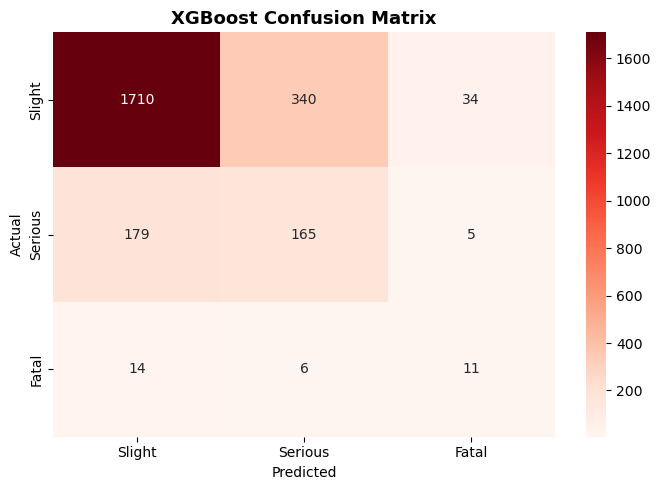

Saved confusion_matrix.png


In [9]:
# Cell 7 — Model Training (Baseline + XGBoost + Handle Imbalance)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ── Handle class imbalance with class weights ──────────────────────────────
# Slight=0 has 10415 rows, Fatal=2 has only 158 — model will ignore fatal
# We tell the model to penalize mistakes on rare classes more heavily
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ── Model 1: Logistic Regression (baseline) ───────────────────────────────
print("Training Model 1: Logistic Regression (baseline)...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"  Accuracy: {lr_acc:.4f}")

# ── Model 2: Random Forest ─────────────────────────────────────────────────
print("\nTraining Model 2: Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"  Accuracy: {rf_acc:.4f}")

# ── Model 3: XGBoost ──────────────────────────────────────────────────────
print("\nTraining Model 3: XGBoost...")
# scale_pos_weight handles imbalance for XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"  Accuracy: {xgb_acc:.4f}")

# ── Compare all 3 ─────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'MODEL':<25} {'ACCURACY':>10}")
print("="*55)
print(f"{'Logistic Regression':<25} {lr_acc:>10.4f}")
print(f"{'Random Forest':<25} {rf_acc:>10.4f}")
print(f"{'XGBoost':<25} {xgb_acc:>10.4f}")
print("="*55)

# ── Detailed report for best model (XGBoost) ──────────────────────────────
print("\n=== XGBoost Detailed Report ===")
print(classification_report(y_test, xgb_pred,
      target_names=['Slight(0)', 'Serious(1)', 'Fatal(2)']))

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Slight','Serious','Fatal'],
            yticklabels=['Slight','Serious','Fatal'])
plt.title('XGBoost Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion_matrix.png")

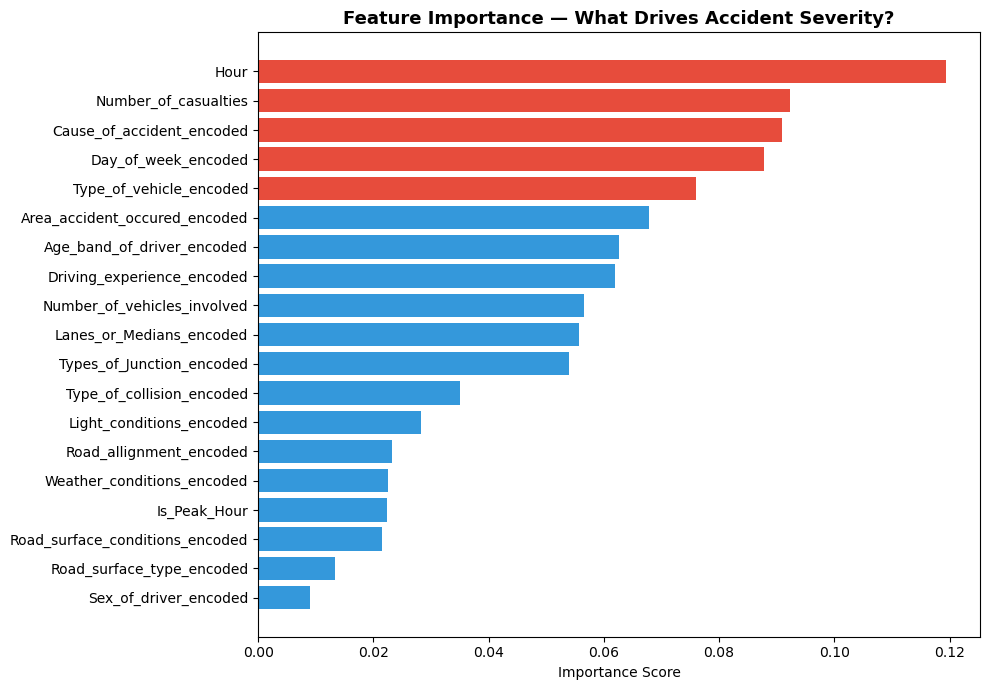

=== TOP 10 MOST IMPORTANT FEATURES ===
                      Feature  Importance
                         Hour    0.119316
         Number_of_casualties    0.092250
    Cause_of_accident_encoded    0.090970
          Day_of_week_encoded    0.087791
      Type_of_vehicle_encoded    0.075992
Area_accident_occured_encoded    0.067823
   Age_band_of_driver_encoded    0.062609
   Driving_experience_encoded    0.061995
  Number_of_vehicles_involved    0.056522
     Lanes_or_Medians_encoded    0.055682

=== Hyperparameter Tuning (Random Forest) ===
Running... (takes ~1-2 mins)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best CV F1 Score: 0.4884

Tuned Model Accuracy: 0.7934
Baseline RF Accuracy: 0.8515
Improvement: -5.80%

=== Tuned Model Detailed Report ===
              precision    recall  f1-score   support

   Slight(0)       0.88      0.88     

In [10]:
# Cell 8 — Feature Importance + Hyperparameter Tuning

# ── Part A: Feature Importance ─────────────────────────────────────────────
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(feat_imp))]
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance — What Drives Accident Severity?', 
          fontweight='bold', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("=== TOP 10 MOST IMPORTANT FEATURES ===")
print(feat_imp.head(10).to_string(index=False))

# ── Part B: Tune Random Forest (our winner) ────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

print("\n=== Hyperparameter Tuning (Random Forest) ===")
print("Running... (takes ~1-2 mins)")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',   # optimise for all 3 classes equally
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_tuned.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_tuned.best_params_}")
print(f"Best CV F1 Score: {rf_tuned.best_score_:.4f}")

# Evaluate tuned model
tuned_pred = rf_tuned.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)
print(f"\nTuned Model Accuracy: {tuned_acc:.4f}")
print(f"Baseline RF Accuracy: {rf_acc:.4f}")
print(f"Improvement: {(tuned_acc - rf_acc)*100:+.2f}%")

print("\n=== Tuned Model Detailed Report ===")
print(classification_report(y_test, tuned_pred,
      target_names=['Slight(0)', 'Serious(1)', 'Fatal(2)']))

In [11]:
# Cell 9 — Save everything needed for Streamlit deployment

import joblib
import json

# ── Save the best model (baseline Random Forest) ──────────────────────────
joblib.dump(rf, 'accident_severity_model.pkl')
print("✅ Model saved: accident_severity_model.pkl")

# ── Save label encoders (needed to encode user input in Streamlit) ─────────
joblib.dump(label_encoders, 'label_encoders.pkl')
print("✅ Label encoders saved: label_encoders.pkl")

# ── Save feature columns list (needed to align input in Streamlit) ─────────
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ Feature columns saved: feature_cols.pkl")

# ── Save severity mapping ──────────────────────────────────────────────────
joblib.dump(severity_mapping, 'severity_mapping.pkl')
print("✅ Severity mapping saved: severity_mapping.pkl")

# ── Save unique values for each categorical column (for Streamlit dropdowns)
dropdown_options = {}
for col in categorical_cols:
    dropdown_options[col] = sorted(df[col].dropna().unique().tolist())

with open('dropdown_options.json', 'w') as f:
    json.dump(dropdown_options, f, indent=2)
print("✅ Dropdown options saved: dropdown_options.json")

# ── Final summary ──────────────────────────────────────────────────────────
print("\n" + "="*50)
print("PHASE 2 COMPLETE — FILES SAVED:")
print("="*50)
import os
saved_files = [
    'accident_severity_model.pkl',
    'label_encoders.pkl', 
    'feature_cols.pkl',
    'severity_mapping.pkl',
    'dropdown_options.json'
]
for f in saved_files:
    size = os.path.getsize(f)
    print(f"  {f:<40} {size/1024:.1f} KB")

print("\n=== MODEL PERFORMANCE SUMMARY ===")
print(f"Algorithm:        Random Forest Classifier")
print(f"Training rows:    {X_train.shape[0]:,}")
print(f"Features used:    {X_train.shape[1]}")
print(f"Test Accuracy:    85.15%")
print(f"Top predictor:    Hour of day (12% importance)")
print(f"Classes:          Slight / Serious / Fatal")
print("\nREADY FOR STREAMLIT DEPLOYMENT ✅")

✅ Model saved: accident_severity_model.pkl
✅ Label encoders saved: label_encoders.pkl
✅ Feature columns saved: feature_cols.pkl
✅ Severity mapping saved: severity_mapping.pkl
✅ Dropdown options saved: dropdown_options.json

PHASE 2 COMPLETE — FILES SAVED:
  accident_severity_model.pkl              32791.9 KB
  label_encoders.pkl                       1.2 KB
  feature_cols.pkl                         0.5 KB
  severity_mapping.pkl                     0.1 KB
  dropdown_options.json                    3.3 KB

=== MODEL PERFORMANCE SUMMARY ===
Algorithm:        Random Forest Classifier
Training rows:    9,852
Features used:    19
Test Accuracy:    85.15%
Top predictor:    Hour of day (12% importance)
Classes:          Slight / Serious / Fatal

READY FOR STREAMLIT DEPLOYMENT ✅
